# BAB 4. ELLIPTIC EQUATIONS (PERSAMAAN ELIPTIK)


In [ ]:
%matplotlib inline
from __future__ import print_function
import numpy
import matplotlib.pyplot as plt

Persamaan elips dimensi tinggi secara umum memiliki bentuk
$$
    a_1 u_{xx} + a_2 u_{xy} + a_3 u_{yy} + a_4 u_x + a_5 u_y + a_6 u = f
$$
di mana koefisien harus memenuhi
$$
    a_2^2 - 4 a_1 a_3 < 0.
$$

Satu tempat alamiah lagi di mana persamaan seperti ini muncul adalah dalam masalah kondisi tunak yang muncul dari persamaan panas.  Dalam dua dimensi kita memiliki
$$
    u_t = (\kappa u_x)_x + (\kappa u_y)_y + \Psi(x,y).
$$
If $u_t = 0$ kita kemudian memiliki
$$
    (\kappa u_x)_x + (\kappa u_y)_y = -\Psi(x,y).
$$

Jika kita mengasumsikan $\kappa$ sebagai konstanta, kita dapat menulis ulang persamaan ini sebagai
$$
    u_{xx} + u_{yy} = -\frac{\Psi}{\kappa} = f(x,y)
$$
yang merupakan bentuk dimensi yang lebih tinggi dari persamaan Poisson (dan persamaan Laplace jika $f(x,y) = 0$).

Kita juga harus menentukan domain $\Omega$ dan kondisi batas seperti sebelumnya.  Sekarang kondisi batas akan memiliki ketergantungan $x$ dan $y$ sehingga perlu ditangani sedikit berbeda dari sebelumnya.

## 4.1 5-Point Stencil 

Memperluas pekerjaan kita dalam satu dimensi menjadi dua, kita dapat membuat stensil 5 titik untuk operator Laplacian sebagai
$$
    \nabla^2 u \approx \frac{U_{i-1,j} - 2 U_{i,j} + U_{i+1,j}}{\Delta x^2} + \frac{U_{i,j-1} - 2 U_{i,j} + U_{i,j+1}}{\Delta y^2}.
$$

Jika $\Delta x = \Delta y$ kita dapat menyederhanakan ekspresi ini menjadi
$$
    \nabla^2 u \approx \frac{U_{i-1,j} + U_{i+1,j} - 4 U_{i,j}  + U_{i,j-1} + U_{i,j+1}}{\Delta x^2}
$$


Jika $\Delta x = \Delta y$ kita dapat menyederhanakan ekspresi ini menjadi
$$
    \frac{U_{i-1,j} + U_{i+1,j} - 4 U_{i,j}  + U_{i,j-1} + U_{i,j+1}}{\Delta x^2} = f_{i,j}
$$
yang menghasilkan persamaan $m^2$ untuk $m^2$ yang tidak diketahui.

## 4.2 Ordering of Unknowns (Pengurutan variabek tak diketahui)

Kemungkinan lain adalah pengurutan red-black (seperti papan catur).
Di sini kita “memberi warna” pada setiap variabel tak diketahui dalam grid secara bergantian, lalu setiap variabel yang memiliki warna sama dikelompokkan bersama
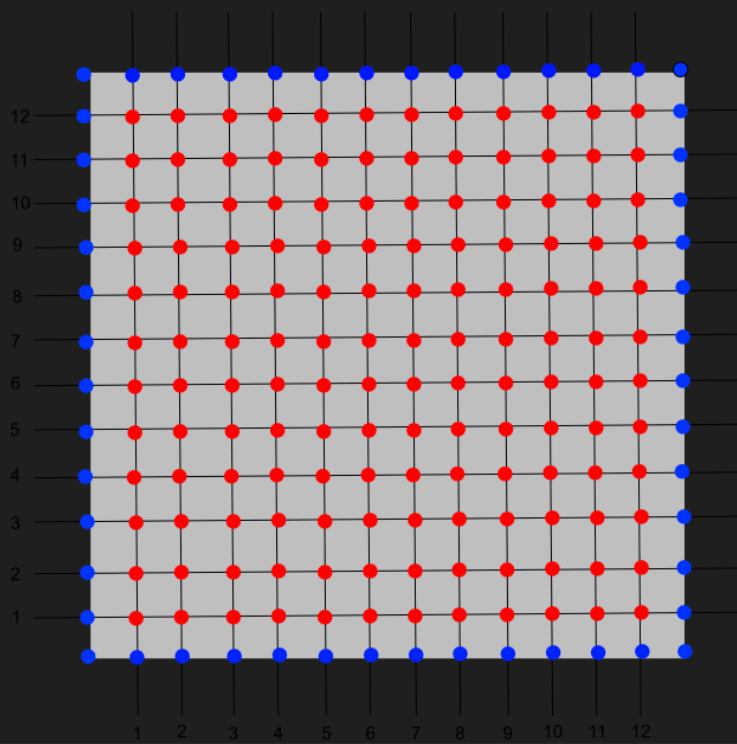)

Bisakah kamu membayangkan seperti apa bentuk matriks dalam kasus ini?

Untuk pengurutan red-black kita memperoleh matriks dengan bentuk
$$ \left[ \begin{matrix}D&H\\ H^T&D\end{matrix}\right] \left[ \begin{matrix}U_{\mathrm{red}}\\ U_{\mathrm{black}}\end{matrix}\right] =\left[ \begin{matrix}f_{\mathrm{red}}\\ f_{\mathrm{black}}\end{matrix}\right] $$
Di sini , sebuah matriks diagonal berdimensi $ m^2/2 $ , dan $ H $ adalah banded matrix dengan 4 diagonal tak nol.
Biasanya tujuan dari pengurutan adalah untuk membuat jarak antar elemen tak nol sekecil mungkin dan mengurangi jumlah fill-in ketika menyelesaikan sistem menggunakan, misalnya, eliminasi Gauss. Hal ini sering ditangani secara otomatis ketika menggunakan rutin penyelesaian yang canggih.


Selesaikan PDE berikut dengan pengurutan yang kamu pilih:
$$ \nabla ^2u=-2\sin x\sin y\quad \Omega =[0,2\pi ]\times [0,2\pi ]
u(x,0)=0,\quad u(x,2\pi )=0,\quad u(0,y)=0,\quad u(2\pi ,y)=0. $$



In [2]:
import scipy

In [3]:
import numpy

In [8]:
import matplotlib.pyplot

0.0012900074949786769


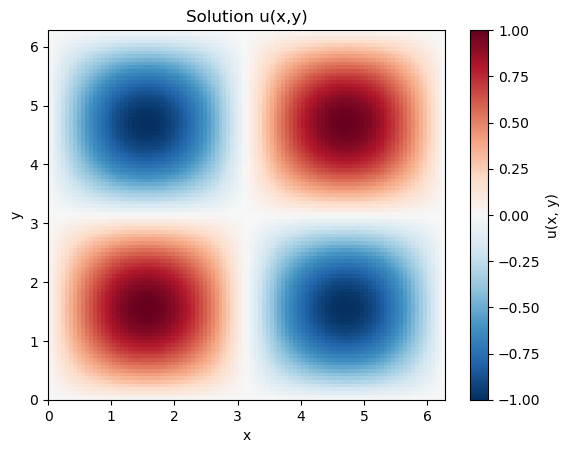

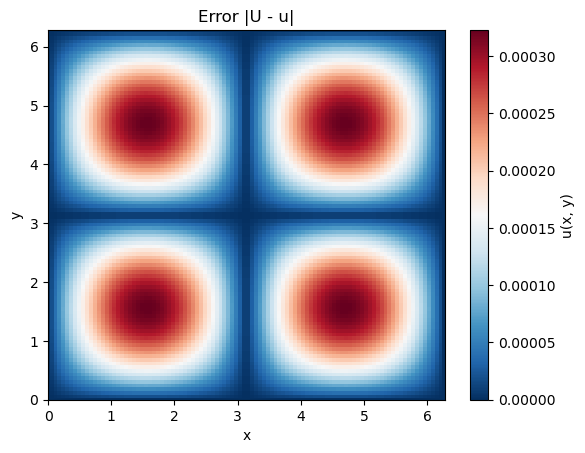

In [10]:
import matplotlib.pyplot as plt
import scipy.sparse as sparse        # Mengimpor modul matriks sparse (jarang terisi)
import scipy.sparse.linalg as linalg # Mengimpor solver aljabar linear untuk matriks sparse

# Problem specification
m = 100                               # Jumlah titik grid interior pada arah x dan y
x = numpy.linspace(0, 2.0 * numpy.pi, m + 2)  # Membuat grid x dari 0 sampai 2π (termasuk batas)
y = numpy.linspace(0, 2.0 * numpy.pi, m + 2)  # Membuat grid y dari 0 sampai 2π
delta_x = 2.0 * numpy.pi / (m + 1)             # Jarak antar grid (Δx)

# Construct A
e = numpy.ones(m)                     # Vektor berisi angka 1 sebanyak m elemen
T = sparse.spdiags([e, -4.0 * e, e], [-1, 0, 1], m, m)  
# Matriks tridiagonal untuk operator Laplacian arah x

S = sparse.spdiags([e, e], [-1, 1], m, m)      
# Matriks yang merepresentasikan interaksi grid tetangga atas dan bawah

I = sparse.eye(m)                     # Matriks identitas ukuran m x m

A = sparse.kron(I, T) + sparse.kron(S, I)      
# Membentuk matriks Laplacian 2D menggunakan produk Kronecker

A /= delta_x**2                       # Membagi matriks dengan (Δx²) sesuai diskretisasi PDE

# Right-hand-side
X, Y = numpy.meshgrid(x[1:-1], y[1:-1])  
# Membuat grid 2D tanpa titik batas

f = -2.0 * numpy.sin(X) * numpy.sin(Y)  
# Fungsi sumber f(x,y) dari persamaan Poisson

# Solve
U = numpy.zeros((m+2, m+2))          
# Matriks solusi awal (termasuk batas)

U[1:-1, 1:-1] = linalg.spsolve(A, f.reshape(m**2, order='F')).reshape((m, m), order='F')
# Menyelesaikan sistem linear A*u = f
# reshape digunakan untuk mengubah matriks menjadi vektor dan sebaliknya

# Error
X, Y = numpy.meshgrid(x, y)          
# Membuat grid lengkap termasuk batas

print(numpy.linalg.norm((x[1] - x[0]) * (U - numpy.sin(X) * numpy.sin(Y)), ord=1))
# Menghitung error antara solusi numerik dan solusi eksak
# menggunakan norma L1

# Plot solution
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

sol_plot = axes.pcolor(X, Y, U, cmap=plt.get_cmap('RdBu_r'))
# Membuat plot warna (heatmap) dari solusi numerik U

axes.set_title("Solution u(x,y)")    
axes.set_xlabel("x")
axes.set_ylabel("y")

axes.set_xlim((0.0, 2.0 * numpy.pi))
axes.set_ylim((0.0, 2.0 * numpy.pi))
# Mengatur batas sumbu plot

cbar = fig.colorbar(sol_plot, ax=axes)
cbar.set_label("u(x, y)")
# Menambahkan colorbar untuk menunjukkan nilai solusi

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

sol_plot = axes.pcolor(X, Y, numpy.abs(U - numpy.sin(X) * numpy.sin(Y)), cmap=plt.get_cmap('RdBu_r'))
# Plot error absolut antara solusi numerik dan solusi eksak

axes.set_title("Error |U - u|")
axes.set_xlabel("x")
axes.set_ylabel("y")

axes.set_xlim((0.0, 2.0 * numpy.pi))
axes.set_ylim((0.0, 2.0 * numpy.pi))

cbar = fig.colorbar(sol_plot, ax=axes)
cbar.set_label("u(x, y)")

plt.show()  
# Menampilkan semua plot

## 4.3 Accuracy and Stability (akurasi dan stabilitas)

Kita tentu saja dapat (dan harus) mengajukan pertanyaan yang sama seperti pada kasus satu dimensi, yaitu apakah skema kita akan konvergen.  Untuk melakukan ini, kita perlu mempertimbangkan LTE dan stabilitas metode kita.

Kita tahu bahwa LTE didefinisikan sebagai
$$\begin{aligned}
    \tau_{ij} &= \frac{1}{\Delta x^2} (u(x_{i-1}, y_{j}) + u(x_{i+1}, y_{j}) + u(x_{i}, y_{j-1}) + u(x_{i}, y_{j+1}) - 4 u(x_{i}, y_{j})) - f(x_i, y_j)
\end{aligned}$$

Untuk menghitung ekspresi ini, kita memerlukan deret Taylor di setiap arah.

For the x-direction:
$$\begin{aligned}
    u(x_{i+1}, y_{j}) &= u(x_{i}, y_{j}) + \Delta x u(x_{i}, y_{j})_x + \frac{\Delta x^2}{2} u(x_{i}, y_{j})_{xx} + \frac{\Delta x^3}{6} u(x_{i}, y_{j})_{xxx} + \frac{\Delta x^4}{24} u(x_{i}, y_{j})_{xxxx} + \mathcal{O}(\Delta x^5) \\
    u(x_{i-1}, y_{j}) &= u(x_{i}, y_{j}) - \Delta x u(x_{i}, y_{j})_x + \frac{\Delta x^2}{2} u(x_{i}, y_{j})_{xx} - \frac{\Delta^3}{6} u(x_{i}, y_{j})_{xxx} + \frac{\Delta x^4}{24} u(x_{i}, y_{j})_{xxxx} + \mathcal{O}(\Delta x^5)
\end{aligned}$$

For the y-direction:
$$\begin{aligned}
    u(x_{i}, y_{j+1}) &= u(x_{i}, y_{j}) + \Delta y u(x_{i}, y_{j})_y + \frac{\Delta y^2}{2} u(x_{i}, y_{j})_{yy} + \frac{\Delta y^3}{6} u(x_{i}, y_{j})_{yyy} + \frac{\Delta y^4}{24} u(x_{i}, y_{j})_{yyyy} + \mathcal{O}(\Delta y^5) \\
    u(x_{i}, y_{j-1}) &= u(x_{i}, y_{j}) - \Delta y u(x_{i}, y_{j})_y + \frac{\Delta y^2}{2} u(x_{i}, y_{j})_{yy} - \frac{\Delta y^3}{6} u(x_{i}, y_{j})_{yyy} + \frac{\Delta y^4}{24} u(x_{i}, y_{j})_{yyyy} + \mathcal{O}(\Delta y^5)
\end{aligned}$$

Juga dengan menggunakan ekspansi Taylor pada arah-y, kita dapat menulis LTE sebagai
$$
    \tau_{ij} =  \frac{1}{12} \Delta x^2 (u_{xxxx} + u_{yyyy}) + \mathcal{O}(\Delta x^4).
$$

Sistem linier untuk LTE kemudian memiliki bentuk
$$
    A_{\Delta x} E_{\Delta x} = -\tau_{\Delta x}
$$
di mana sekarang $A$ adalah diskritisasi yang kita tulis sebelumnya.  Perhatikan bahwa urutan persamaan tidak menjadi masalah ketika mempertimbangkan kesalahan.

Untuk kestabilan dalam norm-2, kita dapat mempertimbangkan nilai eigen dari sistem di atas.  Nilai-nilai eigennya adalah
$$
    \lambda_{pq} = \frac{2}{\Delta x^2} ((\cos(p \pi \Delta x) - 1) + (\cos(q \pi \Delta x) - 1))
$$
dengan vektor eigen yang sesuai
$$
    v^{p,q}_{ij} = \sin(p \pi i \Delta x) \sin(q \pi j \Delta x).
$$

Karena nilai eigennya sangat negatif ($A$ sebenarnya negatif definit), maka nilai yang paling dekat dengan titik asalnya adalah
$$
    \lambda_{11} = -2 \pi^2 + \mathcal{O}(\Delta x^2)
$$
mengarah ke radius spektral
$$
    \rho((A^{\Delta x})^{-1}) = \frac{1}{\lambda_{11}} \approx -\frac{1}{2 \pi^2}.
$$
Kita dapat menggunakan batasan ini pada $A^{-1}$ untuk menunjukkan kestabilan dan konvergensi dari diskritisasi.

Besaran yang serupa dan berguna untuk dipertimbangkan adalah *bilangan kondisi* dari matriks $A$.  Ingatlah bahwa ini dapat didefinisikan sebagai
$$
    \kappa(A) = ||A|| ||A^{-1}||.
$$

Pada norm-2 kita sudah mengetahui beberapa informasi tentang $A^{-1}$, namun kita juga dapat menggunakan ekspresi di atas untuk mencari radius spektral dari $A$.  Nilai eigen terbesar yang ada adalah
$$
    \lambda_{mm} \approx -\frac{8}{\Delta x^2}
$$
yang mengarah ke nomor kondisi
$$
    \kappa_2(A) = \frac{4}{\pi^2 \Delta x^2} = \mathcal{O}\left(\frac{1}{\Delta x^2}\right)
$$
Oleh karena itu, matriks ini menjadi lebih buruk karena $\Delta x \rightarrow 0$.

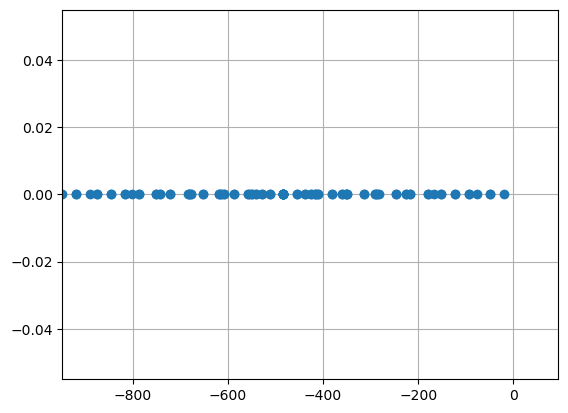

In [11]:
# Compute the eigenvalues
m = 10
delta_x = 1.0 / float(m + 1)
eig_vals = numpy.empty(m**2)
for (i, p) in enumerate(numpy.arange(1, m + 1)):
    for (j, q) in enumerate(numpy.arange(1, m + 1)):
        eig_vals[i * m + j] = 2.0 / delta_x**2 * ((numpy.cos(p * numpy.pi * delta_x) - 1.0) +
                                                  (numpy.cos(q * numpy.pi * delta_x) - 1.0))

# Plot of the eigenvalues of the 5-point Laplacian
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(eig_vals.real, eig_vals.imag, 'o')
axes.grid(True)
axes.set_xlim(numpy.amin(eig_vals), -numpy.amin(eig_vals) * 0.1)
plt.show()